In [1]:
#PHASE 1 - EXPLORATORY DATA ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')
%matplotlib inline 

In [3]:
df = pd.read_csv(r"/Users/navikachawla/Downloads/GiveMeSomeCredit/cs-training.csv")
print(f"Shape: {df.shape}")

Shape: (150000, 12)


In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [6]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum()/len(df))*100

In [8]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

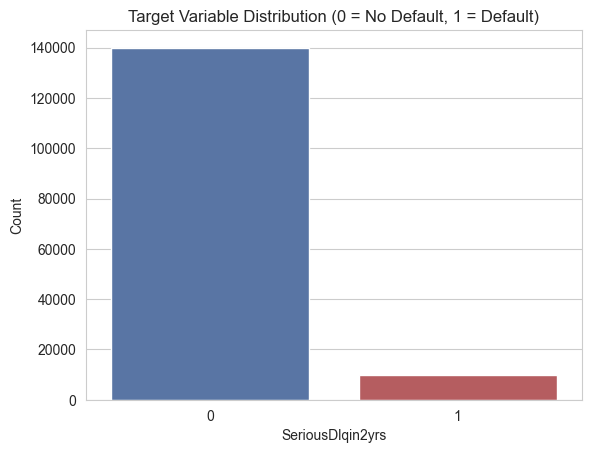

In [9]:
sns.countplot(x='SeriousDlqin2yrs', data=df, hue='SeriousDlqin2yrs', 
              palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Target Variable Distribution (0 = No Default, 1 = Default)')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Count')
plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'MonthlyIncome'}>],
       [<Axes: title={'center': 'DebtRatio'}>,
        <Axes: title={'center': 'RevolvingUtilizationOfUnsecuredLines'}>],
       [<Axes: title={'center': 'NumberOfOpenCreditLinesAndLoans'}>,
        <Axes: >]], dtype=object)

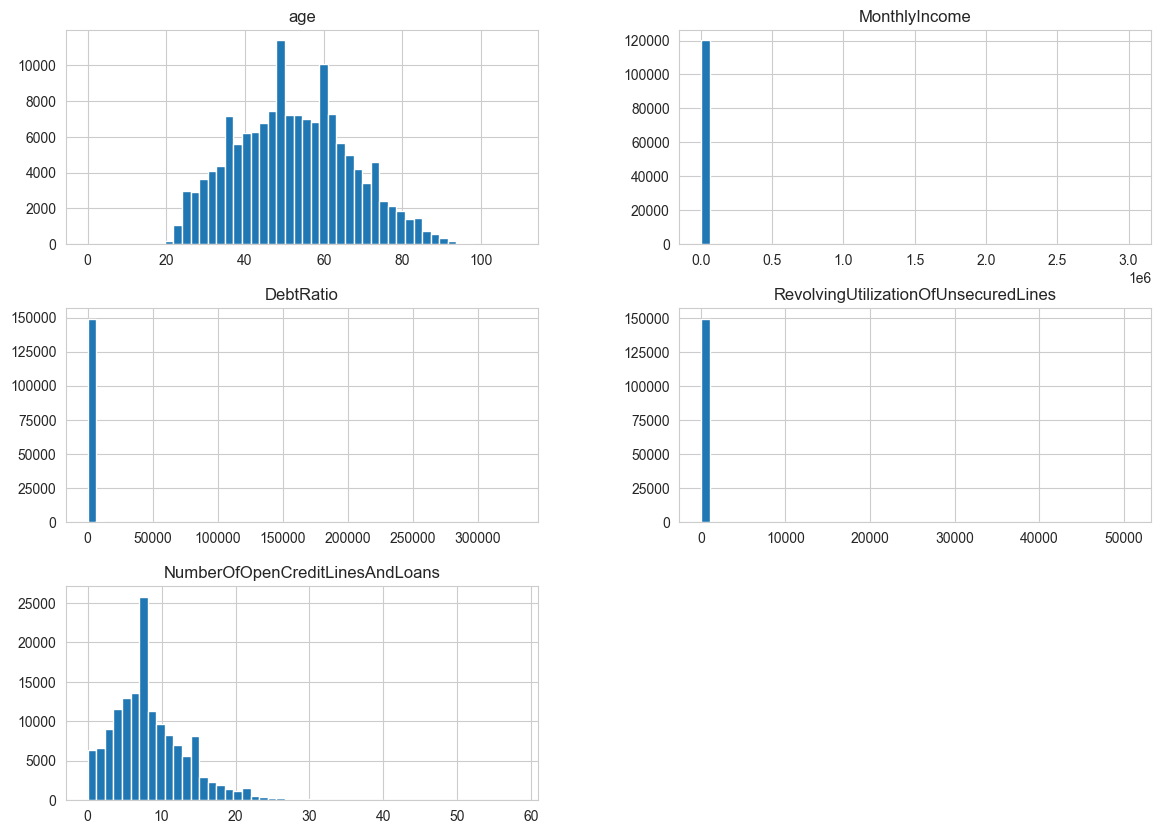

In [10]:
numeric_cols = ['age', 'MonthlyIncome', 'DebtRatio',
                 'RevolvingUtilizationOfUnsecuredLines',
                 'NumberOfOpenCreditLinesAndLoans']
df[numeric_cols].hist(figsize=(14, 10), bins=50)

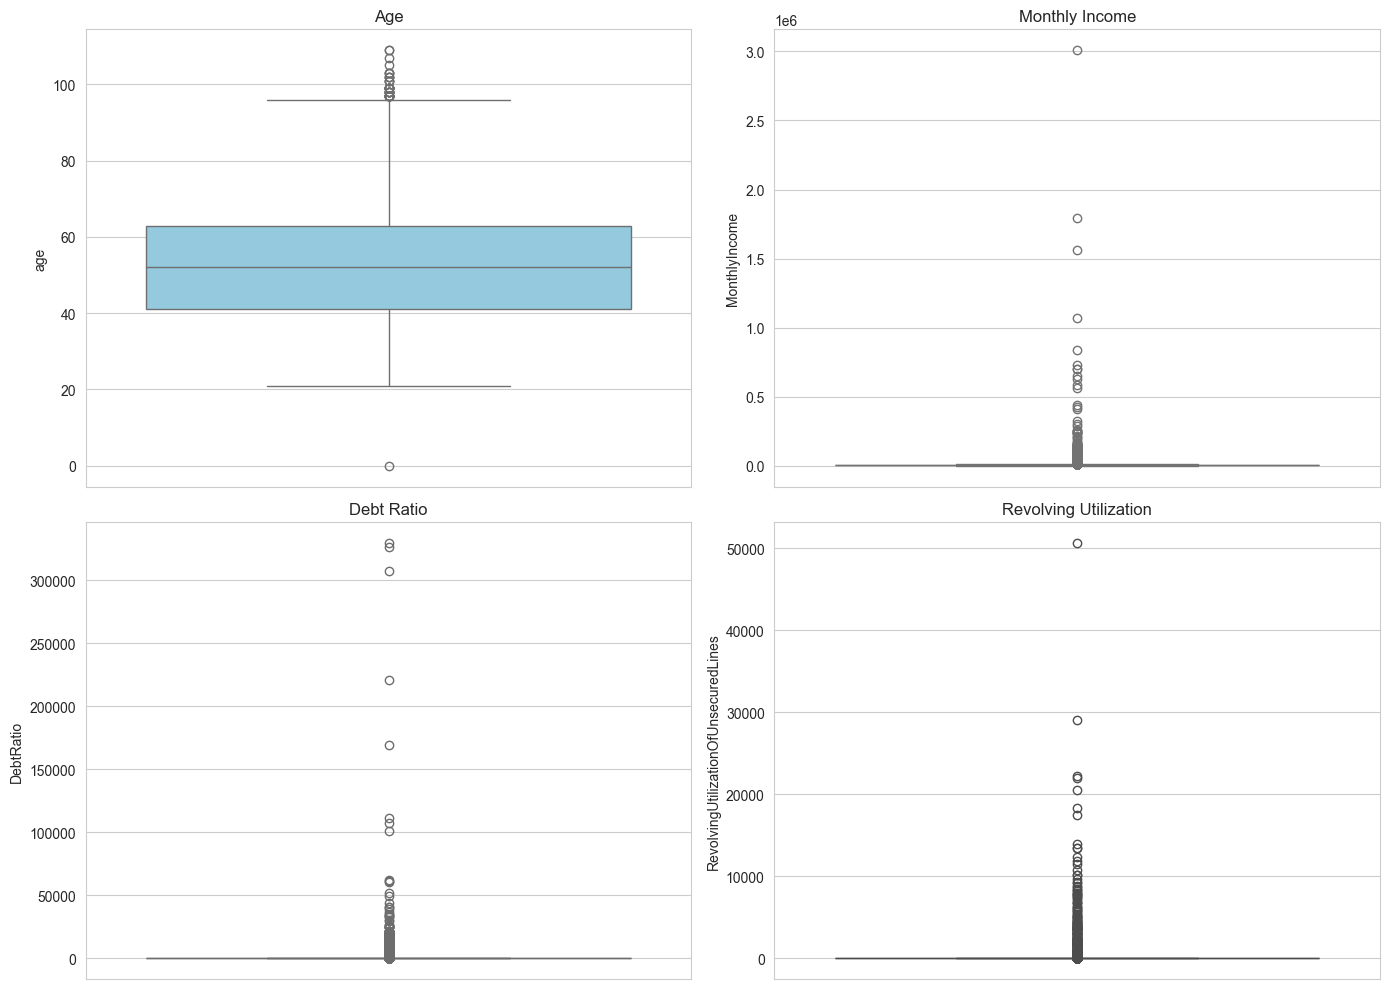

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df['age'], ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age')

sns.boxplot(y=df['MonthlyIncome'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Monthly Income')

sns.boxplot(y=df['DebtRatio'], ax=axes[1,0], color='salmon')
axes[1,0].set_title('Debt Ratio')

sns.boxplot(y=df['RevolvingUtilizationOfUnsecuredLines'], ax=axes[1,1], color='gold')
axes[1,1].set_title('Revolving Utilization')

plt.tight_layout()
plt.show()

In [12]:
# Age = 0 wali rows
print("Rows with age = 0:", df[df['age'] == 0].shape[0])
df[df['age'] == 0].head()

Rows with age = 0: 1


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [13]:
# Utilization > 10 (1000%) wali rows
print("Rows with utilization > 10:", 
      df[df['RevolvingUtilizationOfUnsecuredLines'] > 10].shape[0])
df[df['RevolvingUtilizationOfUnsecuredLines'] > 10][
    ['RevolvingUtilizationOfUnsecuredLines']].describe()

Rows with utilization > 10: 241


,RevolvingUtilizationOfUnsecuredLines
count,241.000000
mean,3564.023932
std,5123.802683
min,11.385230
25%,941.000000
50%,2012.000000
75%,4116.000000
max,50708.000000


In [14]:
# MonthlyIncome ke top 10 highest values
df.sort_values('MonthlyIncome', ascending=False)[['MonthlyIncome']].head(10)

,MonthlyIncome
73763,3008750.0
137140,1794060.0
111365,1560100.0
50640,1072500.0
122543,835040.0
123291,730483.0
93564,702500.0
96549,699530.0
119136,649587.0
37078,629000.0


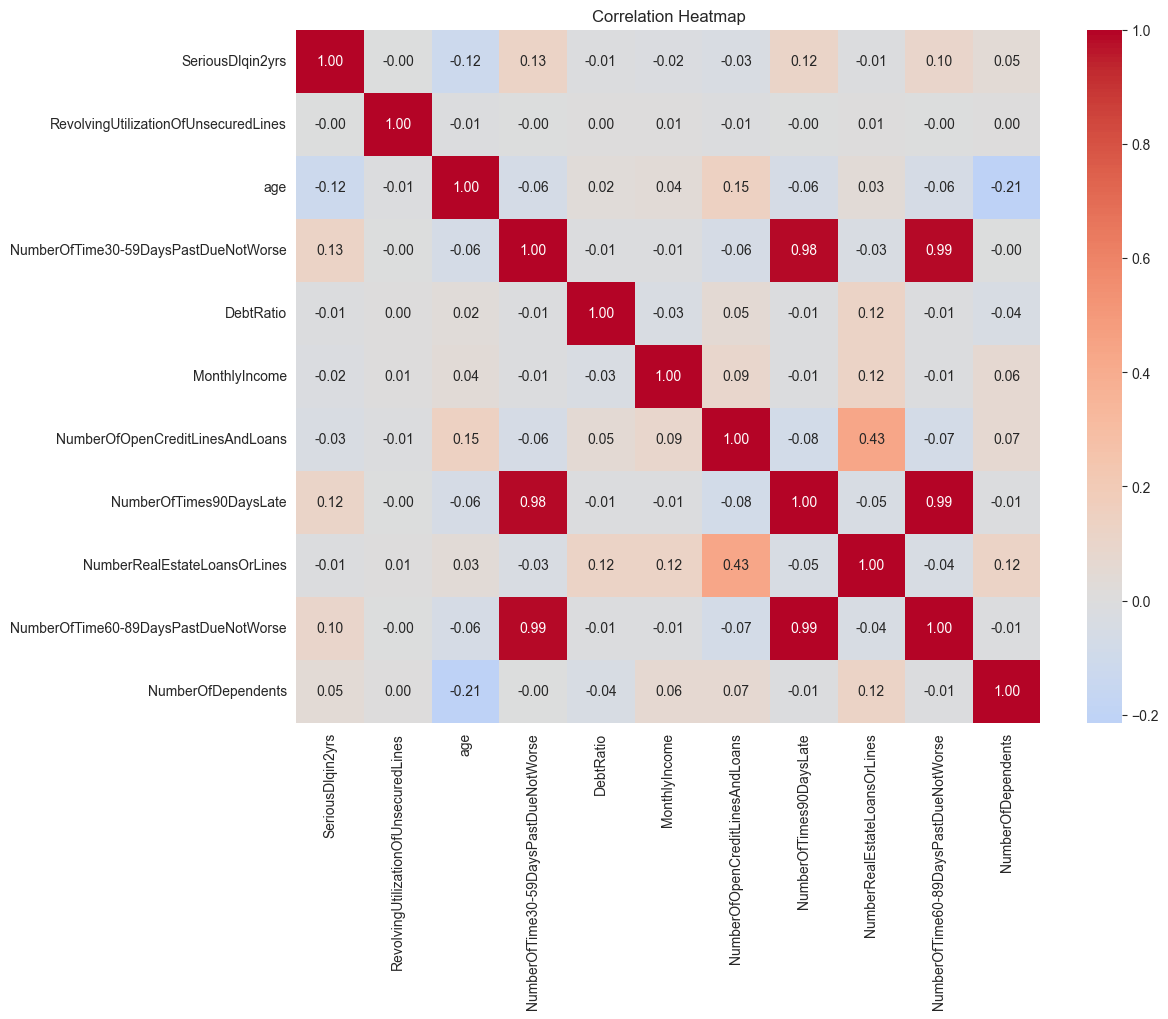

In [15]:
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [16]:
# Target ke saath sabse zyada correlated columns
corr['SeriousDlqin2yrs'].sort_values(ascending=False)

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

In [17]:
comparison = df.groupby('SeriousDlqin2yrs')[numeric_cols].mean()
comparison

,age,MonthlyIncome,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans
SeriousDlqin2yrs,,,,,
0,52.751375,6747.837774,357.151168,6.168855,8.493620
1,45.926591,5630.826493,295.121066,4.367282,7.882306


In [18]:
#PHASE 2 - DATA CLEANING 

In [19]:
print(df.columns.tolist())   #we've dropped the unnamed ones , checked that here
print("Shape:", df.shape)

['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Shape: (150000, 11)


In [20]:
#filling in the missing values 
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


/var/folders/z9/18fdyw_n0575p2v6w2wnpf440000gn/T/ipykernel_39936/856370408.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
/var/folders/z9/18fdyw_n0575p2v6w2wnpf440000gn/T/ipykernel_39936/856370408.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

In [21]:
#we'll cap the outliers 
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)

df['DebtRatio']= df['DebtRatio'].clip(upper = 10000)

income_cap = df['MonthlyIncome'].quantile(0.99)
print(f"Income cap at 99th percentile: {income_cap}")
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=income_cap)

print("\nAfter capping:")
print(df[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']].describe())

Income cap at 99th percentile: 23000.0

After capping:
       RevolvingUtilizationOfUnsecuredLines      DebtRatio  MonthlyIncome
count                         150000.000000  150000.000000  150000.000000
mean                               0.319196     334.714559    6142.445313
std                                0.349481    1025.439058    3835.678657
min                                0.000000       0.000000       0.000000
25%                                0.029867       0.175074    3903.000000
50%                                0.154181       0.366508    5400.000000
75%                                0.559046       0.868254    7400.000000
max                                1.000000   10000.000000   23000.000000


In [22]:
#final check 
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescribe after cleaning:")
df[['age', 'MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']].describe()

Final shape: (150000, 11)

Missing values:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Describe after cleaning:


,age,MonthlyIncome,DebtRatio,RevolvingUtilizationOfUnsecuredLines
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,52.295207,6142.445313,334.714559,0.319196
std,14.771866,3835.678657,1025.439058,0.349481
min,0.000000,0.000000,0.000000,0.000000
25%,41.000000,3903.000000,0.175074,0.029867
50%,52.000000,5400.000000,0.366508,0.154181
75%,63.000000,7400.000000,0.868254,0.559046
max,109.000000,23000.000000,10000.000000,1.000000


In [23]:
df = df[df['age'] > 0]
print("Age = 0 rows after fix:", df[df['age'] == 0].shape[0])
print("Shape:", df.shape)

Age = 0 rows after fix: 0
Shape: (149999, 11)


In [24]:
#PHASE 3 - FEATURE ENGINEERING

In [25]:
# Feature 1 — Debt to Income
df['debt_to_income'] = df['DebtRatio'] * df['MonthlyIncome']

# Feature 2 — Total Late Payments
df['total_late_payments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

# Feature 3 — Credit Utilization Risk Category
df['credit_utilization_risk'] = pd.cut(
    df['RevolvingUtilizationOfUnsecuredLines'],
    bins=[0, 0.3, 0.7, 1.0, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Confirming
print("New columns added:")
print(df[['debt_to_income', 'total_late_payments', 'credit_utilization_risk']].head(10))
print("\nNew shape:", df.shape)

New columns added:
   debt_to_income  total_late_payments credit_utilization_risk
0    7.323197e+03                    2                    High
1    3.168781e+02                    0                    High
2    2.589149e+02                    2                  Medium
3    1.189640e+02                    0                     Low
4    5.732910e+02                    1                    High
5    1.314624e+03                    0                     Low
6    3.083400e+07                    0                  Medium
7    7.347901e+02                    0                    High
8    2.484000e+05                    0                     Low
9    1.394469e+04                    0                     Low

New shape: (149999, 14)


In [26]:
#PHASE 4 - MODEL BUILDING

In [27]:
import sys
!{sys.executable} -m pip install xgboost --upgrade

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl (1.9 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 1.7.6
    Uninstalling xgboost-1.7.6:
      Successfully uninstalled xgboost-1.7.6
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
#from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE



In [29]:
# credit_utilization_risk conversion to numbers 
df['credit_utilization_risk'] = df['credit_utilization_risk'].map(
    {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
)

# X = features , Y= Target (x is the input data , y is output)
# we have 13 feature columns and 1 target column
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (149999, 13)
y shape: (149999,)

Target distribution:
SeriousDlqin2yrs
0    139973
1     10026
Name: count, dtype: int64


In [30]:
print("Missing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Missing values in X:
credit_utilization_risk    10878
dtype: int64


In [31]:
df['credit_utilization_risk'] = df['credit_utilization_risk'].fillna(0)

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (119999, 13)
X_test shape: (30000, 13)

Training target distribution:
SeriousDlqin2yrs
0    111978
1      8021
Name: count, dtype: int64

Testing target distribution:
SeriousDlqin2yrs
0    27995
1     2005
Name: count, dtype: int64


In [33]:
#we scale the features since in logistic regression the scale should be same
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [34]:
#SMOTE balances the imbalanced dataset
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 111978, 1: 8021}
After SMOTE: {0: 111978, 1: 111978}


/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [35]:
#logistic regression 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm_scaled, y_train_sm)
print("Logistic Regression (scaled) training complete!")

/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwis

Logistic Regression (scaled) training complete!


In [36]:
import sys
!{sys.executable} -m pip install xgboost==1.7.6 --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-1.7.6-py3-none-macosx_12_0_arm64.whl (1.6 MB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)
print("XGBoost training complete!")

XGBoost training complete!


In [ ]:
#PHASE 5 - EVALUATION 

In [40]:
# debt_to_income capping
debt_cap = df['debt_to_income'].quantile(0.99)
df['debt_to_income'] = df['debt_to_income'].clip(upper=debt_cap)

# X aur y 
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("Data ready!")
print("X_train_sm shape:", X_train_sm.shape)

Data ready!
X_train_sm shape: (223956, 13)


/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [44]:
# credit_utilization_risk conversion to int
X_train_sm['credit_utilization_risk'] = X_train_sm['credit_utilization_risk'].astype(int)
X_test['credit_utilization_risk'] = X_test['credit_utilization_risk'].astype(int)

# Verification
print(X_train_sm.dtypes)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm_scaled, y_train_sm)
print("LR done!")

# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)
print("XGBoost done!")

RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
debt_to_income                          float64
total_late_payments                       int64
credit_utilization_risk                   int64
dtype: object


/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features

LR done!
XGBoost done!


In [45]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# XGBoost predictions
xgb_pred = xgb.predict(X_test.values)
xgb_pred_proba = xgb.predict_proba(X_test.values)[:,1]

# Logistic Regression predictions
lr_pred = lr.predict(X_test_scaled)
lr_pred_proba = lr.predict_proba(X_test_scaled)[:,1]

# AUC Scores
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
lr_auc = roc_auc_score(y_test, lr_pred_proba)

print(f"XGBoost  — AUC: {xgb_auc:.3f} | Gini: {(2*xgb_auc-1):.3f}")
print(f"Logistic — AUC: {lr_auc:.3f}  | Gini: {(2*lr_auc-1):.3f}")

XGBoost  — AUC: 0.835 | Gini: 0.669
Logistic — AUC: 0.777  | Gini: 0.555


/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/navikachawla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     27995
           1       0.39      0.34      0.36      2005

    accuracy                           0.92     30000
   macro avg       0.67      0.65      0.66     30000
weighted avg       0.92      0.92      0.92     30000



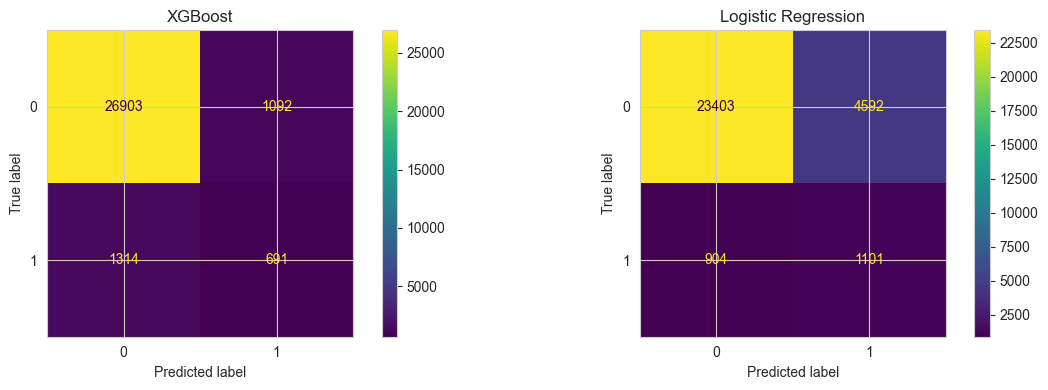

In [46]:
# XGBoost Classification Report
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_xgb = confusion_matrix(y_test, xgb_pred)
ConfusionMatrixDisplay(cm_xgb).plot(ax=axes[0])
axes[0].set_title("XGBoost")

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[1])
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

In [47]:
#PHASE 6 - CREDIT SCORECARD

Score range: 364 - 711
Average score: 565
Median score: 569


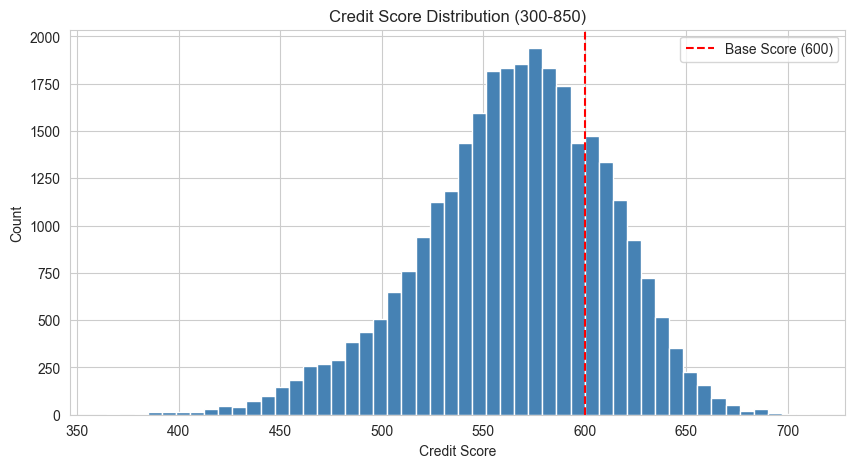

In [48]:
import numpy as np

def probability_to_score(probability,
                          base_score=600,
                          pdo=20,
                          base_odds=50):
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    score = offset - factor * np.log(probability / (1 - probability + 1e-10))
    return np.clip(score, 300, 850).astype(int)

# XGBoost probabilities ko score mein convert karo
probabilities = xgb.predict_proba(X_test.values)[:,1]
scores = probability_to_score(probabilities)

print(f"Score range: {scores.min()} - {scores.max()}")
print(f"Average score: {scores.mean():.0f}")
print(f"Median score: {np.median(scores):.0f}")

# Distribution plot
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=50, color='steelblue', edgecolor='white')
plt.title('Credit Score Distribution (300-850)')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.axvline(x=600, color='red', linestyle='--', label='Base Score (600)')
plt.legend()
plt.show()

In [49]:
# saving scorecard output
import pandas as pd

scorecard_df = X_test.copy()
scorecard_df['actual_default'] = y_test.values
scorecard_df['default_probability'] = probabilities
scorecard_df['credit_score'] = scores

scorecard_df.to_csv('scorecard_output.csv', index=False)
print("Saved! Shape:", scorecard_df.shape)
print(scorecard_df[['actual_default', 'default_probability', 'credit_score']].head(10))

Saved! Shape: (30000, 16)
        actual_default  default_probability  credit_score
104532               0             0.016794           604
98812                0             0.007790           626
41147                0             0.027440           590
16524                0             0.054539           569
120157               0             0.103340           549
80814                0             0.049936           572
148787               0             0.015196           607
12131                1             0.964583           391
61398                0             0.032004           585
145317               0             0.032421           585
